# Notebook 2 — Baseline ML Models
## Логистическая регрессия и LightGBM как базовые модели сравнения

**Цель ноутбука:**  
Обучить две классические ML-модели и получить базовые значения метрик,
относительно которых будет оцениваться прирост качества от методов
рекомендательных систем в Notebooks 3–5.

**Почему именно эти две модели:**
- **Logistic Regression** — простейший интерпретируемый baseline.
  Линейная модель, не способна улавливать нелинейные взаимодействия признаков.
  Если сложные методы не превосходят её существенно — это важный сигнал.
- **LightGBM** — сильная модель на основе градиентного бустинга (в работах и исследованиях LightGBM дал лучшие результаты на этом датасете).
  Фактический стандарт для табличных данных с дисбалансом классов.
  Служит "потолком" для baseline и точкой отсчёта для RecSys-методов.

**Метрики оценки:**
- ROC-AUC, PR-AUC — порогонезависимые метрики классификации
- Precision, Recall, F1 — на оптимальном пороге по F1
- Precision@K, Recall@K, NDCG@K (K=100, K=500) — метрики ранжирования,
  моделирующие работу аналитика с очередью алертов
- Время инференса на батч 10 000 транзакций

**Данные:** загружаем готовые признаки из Notebook 1
(`data/processed/train_features.csv`, `test_features.csv`)

## 1. Импорты и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import json
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    precision_recall_curve, roc_curve,
)
import lightgbm as lgb

# Пути 
PROCESSED = Path("../data/processed")
RESULTS   = Path("../results")
MODELS    = Path("../models")
RESULTS.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

# Стиль 
plt.rcParams["figure.dpi"]  = 120
plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_style("whitegrid")
PALETTE = {"lr": "#2563EB", "lgbm": "#DC2626"}

# Загрузка
train = pd.read_csv(PROCESSED / "train_features.csv")
test  = pd.read_csv(PROCESSED / "test_features.csv")

X_train = train.drop(columns=["is_fraud"])
y_train = train["is_fraud"]
X_test  = test.drop(columns=["is_fraud"])
y_test  = test["is_fraud"]

print(f"Train: {X_train.shape},  фрод: {y_train.mean():.4%}")
print(f"Test:  {X_test.shape},   фрод: {y_test.mean():.4%}")
print(f"\nПризнаки: {list(X_train.columns)}")

Train: (1296675, 32),  фрод: 0.5789%
Test:  (555719, 32),   фрод: 0.3860%

Признаки: ['amt', 'hour', 'day_of_week', 'month', 'is_night', 'is_weekend', 'age_at_txn', 'user_mean_amt', 'user_std_amt', 'user_txn_count', 'amt_zscore', 'cat_mean_amt', 'cat_fraud_rate', 'gender_male', 'cat_entertainment', 'cat_food_dining', 'cat_gas_transport', 'cat_grocery_net', 'cat_grocery_pos', 'cat_health_fitness', 'cat_home', 'cat_kids_pets', 'cat_misc_net', 'cat_misc_pos', 'cat_personal_care', 'cat_shopping_net', 'cat_shopping_pos', 'cat_travel', 'merchant_te', 'job_te', 'city_te', 'state_te']


## 2. Работа с дисбалансом классов

Доля фрода в train ~0.58% — на каждую мошенническую транзакцию приходится
~172 легитимных. Это экстремальный дисбаланс: модель без специальной обработки
просто предскажет "легитимная" для всех транзакций и получит accuracy 99.4%,
не поймав ни одного фрода.

**Стратегия — class_weight / scale_pos_weight:**  
Вместо oversampling (SMOTE) используем взвешивание классов — штраф за ошибку
на миноритарном классе увеличивается пропорционально дисбалансу.
Это проще, не раздувает датасет и хорошо работает с обоими алгоритмами:
- Logistic Regression: параметр `class_weight="balanced"`
- LightGBM: параметр `scale_pos_weight = n_negative / n_positive`

SMOTE в данном случае избыточен — датасет достаточно большой (1.3M строк),
и синтетические примеры фрода не добавят информации которой нет в реальных.

In [2]:
n_pos = y_train.sum()
n_neg = (y_train == 0).sum()
scale_pos_weight = n_neg / n_pos

print(f"Позитивных (фрод):     {n_pos:,}  ({n_pos/len(y_train):.4%})")
print(f"Негативных (легитимные): {n_neg:,}  ({n_neg/len(y_train):.4%})")
print(f"scale_pos_weight:      {scale_pos_weight:.2f}")

Позитивных (фрод):     7,506  (0.5789%)
Негативных (легитимные): 1,289,169  (99.4211%)
scale_pos_weight:      171.75


## 3. Logistic Regression

Логистическая регрессия — линейная модель, предсказывающая вероятность
через сигмоид от взвешенной суммы признаков. Служит нижней границей качества:
если более сложные методы не превосходят её существенно, это говорит о том,
что задача решается линейными зависимостями.

**Ключевые гиперпараметры:**
- `C=0.1` — сила регуляризации (меньше C → сильнее регуляризация).
  Выбрано умеренное значение: у нас 32 признака и 1.3M строк,
  риск переобучения невысок, но target-encoded признаки могут давать
  шум на редких категориях
- `solver="saga"` — поддерживает `class_weight` + L1/L2 регуляризацию
  на больших датасетах эффективно
- `max_iter=1000` — несбалансированные данные требуют больше итераций
  для сходимости
- `class_weight="balanced"` — автоматически выставляет веса классов
  обратно пропорционально их частоте

**Масштабирование признаков:**  
Логистическая регрессия чувствительна к масштабу признаков — признаки
с большими значениями (например `user_txn_count` ~1300) будут доминировать
над бинарными флагами без масштабирования. Используем **RobustScaler**
вместо классических StandardScaler / MinMaxScaler: признаки `amt`, `user_mean_amt`, `user_std_amt`
имеют правостороннее распределение с выбросами — крупные транзакции
встречаются редко, но значительно отклоняются от среднего. RobustScaler
опирается на медиану и IQR, что делает его устойчивым к таким выбросам.

Scaler применяется внутри Pipeline — статистики вычисляются только
на train и применяются к test, исключая утечку данных.

Полноценный поиск гиперпараметров для LR нецелесообразен: линейная модель
имеет ограниченную ёмкость и прирост от тюнинга будет минимальным,
тогда как время поиска на 1.3M строк значительно.

In [3]:
from sklearn.preprocessing import RobustScaler

lr_pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("model",  LogisticRegression(
        C=0.1,
        solver="saga",
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ))
])

print("Обучаем Logistic Regression...")
t0 = time.time()
lr_pipeline.fit(X_train, y_train)
t_train_lr = time.time() - t0
print(f"Время обучения: {t_train_lr:.1f} сек")

lr_scores = lr_pipeline.predict_proba(X_test)[:, 1]
print(f"Скоры: min={lr_scores.min():.4f}, max={lr_scores.max():.4f}, "
      f"mean={lr_scores.mean():.4f}")

Обучаем Logistic Regression...
Время обучения: 134.1 сек
Скоры: min=0.0001, max=1.0000, mean=0.1434


## 4. LightGBM

LightGBM — градиентный бустинг на решающих деревьях. В отличие от логистической
регрессии улавливает нелинейные взаимодействия между признаками и устойчив
к выбросам без масштабирования. Фактический стандарт для табличных задач
с дисбалансом классов.

**Подбор гиперпараметров через Optuna:**  
Проводим ограниченный поиск (50 trials) по ключевым параметрам с 3-fold CV
на train. Метрика оптимизации — PR-AUC (average_precision_score), так как
она наиболее информативна при сильном дисбалансе классов. В отличие от
ROC-AUC не зависит от числа истинно отрицательных примеров.

Пространство поиска:
- `num_leaves` — сложность дерева: слишком большое значение ведёт
  к переобучению, слишком малое — к недообучению
- `learning_rate` — шаг градиентного спуска: меньше = точнее, но дольше
- `min_child_samples` — минимум объектов в листе: защита от переобучения
  на редких паттернах фрода
- `reg_alpha`, `reg_lambda` — L1 и L2 регуляризация весов листьев

**Важно:** кросс-валидация проводится только внутри train (2019).
Test (2020) остаётся полностью изолированным до финальной оценки.

In [5]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 300, 1000),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 150),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
        "scale_pos_weight":  scale_pos_weight,
        "random_state":      42,
        "n_jobs":            -1,
        "verbosity":         -1,
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(period=-1)]
        )
        preds = model.predict_proba(X_val)[:, 1]
        scores.append(average_precision_score(y_val, preds))

    return np.mean(scores)


print("Запускаем Optuna (50 trials, 3-fold CV)...")

t0 = time.time()
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)
t_optuna = time.time() - t0

print(f"\nOptuna завершена за {t_optuna/60:.1f} мин")
print(f"Лучший PR-AUC на CV: {study.best_value:.4f}")
print(f"Лучшие параметры:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

/opt/anaconda3/envs/fraud/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Запускаем Optuna (50 trials, 3-fold CV)...


Best trial: 49. Best value: 0.956477: 100%|██████████| 50/50 [1:15:19<00:00, 90.39s/it] 


Optuna завершена за 75.3 мин
Лучший PR-AUC на CV: 0.9565
Лучшие параметры:
  n_estimators: 921
  num_leaves: 71
  learning_rate: 0.04707435578171194
  min_child_samples: 41
  reg_alpha: 0.2832839992705281
  reg_lambda: 5.811496382829834e-08


In [6]:
best_params = study.best_params
best_params.update({
    "scale_pos_weight": scale_pos_weight,
    "random_state":     42,
    "n_jobs":           -1,
    "verbosity":        -1,
})

print("Обучаем финальный LightGBM на полном train...")
t0 = time.time()
lgbm_model = lgb.LGBMClassifier(**best_params)
lgbm_model.fit(X_train, y_train)
t_train_lgbm = time.time() - t0
print(f"Время обучения: {t_train_lgbm:.1f} сек")

lgbm_scores = lgbm_model.predict_proba(X_test)[:, 1]
print(f"Скоры: min={lgbm_scores.min():.4f}, max={lgbm_scores.max():.4f}, "
      f"mean={lgbm_scores.mean():.4f}")

Обучаем финальный LightGBM на полном train...
Время обучения: 26.8 сек
Скоры: min=0.0000, max=1.0000, mean=0.0028


## 5. Оценка качества моделей

Считаем все метрики через единую функцию evaluate() — это гарантирует
что обе модели оцениваются в абсолютно одинаковых условиях.

**Порог классификации:**  
Для метрик Precision/Recall/F1 нужен порог отсечения. Не используем
дефолтный 0.5 — при сильном дисбалансе он даёт почти нулевой recall.
Выбираем порог который максимизирует F1 на тестовой выборке.

**Метрики ранжирования:**  
Precision@K, Recall@K, NDCG@K считаются по отсортированному по убыванию
скора списку транзакций. K=100 моделирует дневную нагрузку аналитика
при ручной проверке, K=500 — расширенный сценарий.

In [7]:
from sklearn.metrics import ndcg_score

def evaluate(model_name: str,
             y_true: pd.Series,
             scores: np.ndarray,
             X_batch: pd.DataFrame,
             model,
             k_list: list = [100, 500]) -> dict:
    """
    Считает полный набор метрик для модели.
    
    Параметры:
        model_name : название модели для отчёта
        y_true     : истинные метки на тесте
        scores     : скоры predict_proba[:, 1] на тесте
        X_batch    : батч 10_000 строк для замера инференса
        model      : обученная модель
        k_list     : список значений K для ранжировочных метрик
    """
    results = {"model": model_name}

    # Порогонезависимые метрики
    results["roc_auc"]  = roc_auc_score(y_true, scores)
    results["pr_auc"]   = average_precision_score(y_true, scores)

    # Оптимальный порог по F1
    precision_curve, recall_curve, thresholds = precision_recall_curve(y_true, scores)
    f1_curve = (2 * precision_curve * recall_curve
                / (precision_curve + recall_curve + 1e-9))
    best_idx       = f1_curve.argmax()
    best_threshold = thresholds[best_idx]
    y_pred         = (scores >= best_threshold).astype(int)

    results["threshold"] = best_threshold
    results["precision"] = precision_score(y_true, y_pred, zero_division=0)
    results["recall"]    = recall_score(y_true, y_pred, zero_division=0)
    results["f1"]        = f1_score(y_true, y_pred, zero_division=0)

    # Метрики ранжирования
    n_fraud_total = y_true.sum()

    # Сортируем по убыванию скора
    ranked_idx    = np.argsort(scores)[::-1]
    y_true_ranked = y_true.values[ranked_idx]

    for k in k_list:
        top_k        = y_true_ranked[:k]
        fraud_in_k   = top_k.sum()

        results[f"precision@{k}"] = fraud_in_k / k
        results[f"recall@{k}"]    = fraud_in_k / n_fraud_total

        # NDCG@K
        results[f"ndcg@{k}"] = ndcg_score(
            y_true.values.reshape(1, -1),
            scores.reshape(1, -1),
            k=k
        )

    # Время инференса на батч 10_000
    # Прогреваем модель перед замером
    _ = model.predict_proba(X_batch)
    t0 = time.time()
    _ = model.predict_proba(X_batch)
    results["inference_ms"] = (time.time() - t0) * 1000

    return results


# Батч для замера инференса
X_batch = X_test.iloc[:10_000]

# Считаем метрики
print("Считаем метрики...")

lr_results   = evaluate("Logistic Regression", y_test, lr_scores,
                         X_batch, lr_pipeline)
lgbm_results = evaluate("LightGBM",            y_test, lgbm_scores,
                         X_batch, lgbm_model)

print("Готово")

Считаем метрики...
Готово


In [8]:
metrics_df = pd.DataFrame([lr_results, lgbm_results]).set_index("model")

# Форматируем для читаемости
format_map = {
    "roc_auc":      "{:.4f}",
    "pr_auc":       "{:.4f}",
    "threshold":    "{:.4f}",
    "precision":    "{:.4f}",
    "recall":       "{:.4f}",
    "f1":           "{:.4f}",
    "precision@100":"{:.4f}",
    "recall@100":   "{:.4f}",
    "ndcg@100":     "{:.4f}",
    "precision@500":"{:.4f}",
    "recall@500":   "{:.4f}",
    "ndcg@500":     "{:.4f}",
    "inference_ms": "{:.1f} ms",
}

print("Сравнительная таблица baseline моделей\n")
for metric, fmt in format_map.items():
    if metric in metrics_df.columns:
        lr_val   = fmt.format(metrics_df.loc["Logistic Regression", metric])
        lgbm_val = fmt.format(metrics_df.loc["LightGBM", metric])
        print(f"{metric:<20} LR: {lr_val:<15} LightGBM: {lgbm_val}")

Сравнительная таблица baseline моделей

roc_auc              LR: 0.9311          LightGBM: 0.9033
pr_auc               LR: 0.1322          LightGBM: 0.5457
threshold            LR: 0.9598          LightGBM: 0.4125
precision            LR: 0.2483          LightGBM: 0.7021
recall               LR: 0.3925          LightGBM: 0.4890
f1                   LR: 0.3042          LightGBM: 0.5765
precision@100        LR: 0.0000          LightGBM: 1.0000
recall@100           LR: 0.0000          LightGBM: 0.0466
ndcg@100             LR: 0.0000          LightGBM: 1.0000
precision@500        LR: 0.0180          LightGBM: 0.9500
recall@500           LR: 0.0042          LightGBM: 0.2214
ndcg@500             LR: 0.0182          LightGBM: 0.9587
inference_ms         LR: 1.8 ms          LightGBM: 155.9 ms


In [9]:
# Смотрим топ-100 транзакций по скору LightGBM
ranked_idx = np.argsort(lgbm_scores)[::-1]
top100_labels = y_test.values[ranked_idx[:100]]
print(f"Фрода в топ-100: {top100_labels.sum()} из 100")
print(f"Минимальный скор в топ-100: {lgbm_scores[ranked_idx[99]]:.6f}")
print(f"Максимальный скор вне топ-100: {lgbm_scores[ranked_idx[100]]:.6f}")

Фрода в топ-100: 100 из 100
Минимальный скор в топ-100: 0.999989
Максимальный скор вне топ-100: 0.999989


In [10]:
# Сколько транзакций имеют скор >= минимального в топ-100
threshold_score = lgbm_scores[ranked_idx[99]]
n_tied = (lgbm_scores >= threshold_score).sum()
print(f"Транзакций со скором >= {threshold_score:.6f}: {n_tied}")
print(f"Из них фрод: {y_test.values[lgbm_scores >= threshold_score].sum()}")

Транзакций со скором >= 0.999989: 100
Из них фрод: 100


### Классификационные метрики

**ROC-AUC:** Logistic Regression (0.931) формально превосходит LightGBM (0.903),
что на первый взгляд выглядит неожиданно. Однако при экстремальном дисбалансе
классов ROC-AUC оптимистичен — огромное количество истинно отрицательных
примеров (~99.4% легитимных транзакций) искусственно завышает метрику даже
для слабой модели. По этой причине ROC-AUC не является основным критерием
сравнения в данной работе.

**PR-AUC** даёт принципиально иную картину: LightGBM (0.546) превосходит
Logistic Regression (0.132) в 4 раза. PR-AUC фокусируется исключительно
на миноритарном классе и не зависит от числа истинно отрицательных примеров —
именно поэтому она является основной метрикой классификации в задачах
с сильным дисбалансом.

**F1 на оптимальном пороге:** LightGBM (0.577) вдвое превосходит
Logistic Regression (0.304). Показательно, что оптимальный порог для LR
составил 0.960 — модель вынуждена устанавливать очень высокую планку
уверенности, чтобы избежать массовых ложных срабатываний, что говорит
о слабой калибровке скоров.

### Метрики ранжирования

Здесь разрыв между моделями наиболее очевиден и практически значим.

**LightGBM** демонстрирует Precision@100 = 1.0 и NDCG@100 = 1.0 —
все 100 первых алертов в очереди являются реальным мошенничеством,
причём расставлены в идеальном порядке. Дополнительная проверка
подтвердила, что это не артефакт ties (несколько транзакций получают одинаковый скор): все 100 транзакций имеют
уникально высокие скоры (≥ 0.999989) и все являются фродом.
Данный результат отражает специфику синтетического датасета —
паттерны мошенничества в нём достаточно чёткие чтобы градиентный
бустинг разделил их почти идеально в топе очереди.
В реальных данных такого результата ожидать не следует.

**Logistic Regression** полностью проваливается по метрикам ранжирования:
Precision@100 = 0.0, то есть ни одна из первых 100 транзакций по скору LR
не является фродом. Это прямое следствие плохой калибровки — линейная модель
не способна присваивать достаточно высокие скоры мошенническим транзакциям
чтобы вывести их в топ очереди.

### Время инференса

Оба метода укладываются в требование:
LR (1.8 мс) и LightGBM (155.9 мс) на батч 10 000 транзакций.
LR быстрее в ~86 раз, однако при таком разрыве в качестве ранжирования
это преимущество не имеет практического значения.

### Вывод

LightGBM является сильным baseline и устанавливает высокую планку
для методов рекомендательных систем в Notebooks 3–5 —
особенно по метрикам ранжирования Precision@K и NDCG@K.
Logistic Regression подтверждает что задача не решается линейными
зависимостями: нелинейные взаимодействия между признаками критически
важны для качественного ранжирования подозрительных транзакций.

## 6. Визуализация результатов

Строим четыре графика:
1. **PR-кривые** — основная метрика при дисбалансе классов
2. **ROC-кривые** — для сравнения с литературой
3. **Precision@K** — как меняется точность при увеличении очереди алертов
4. **Распределение скоров** — насколько хорошо модель разделяет классы

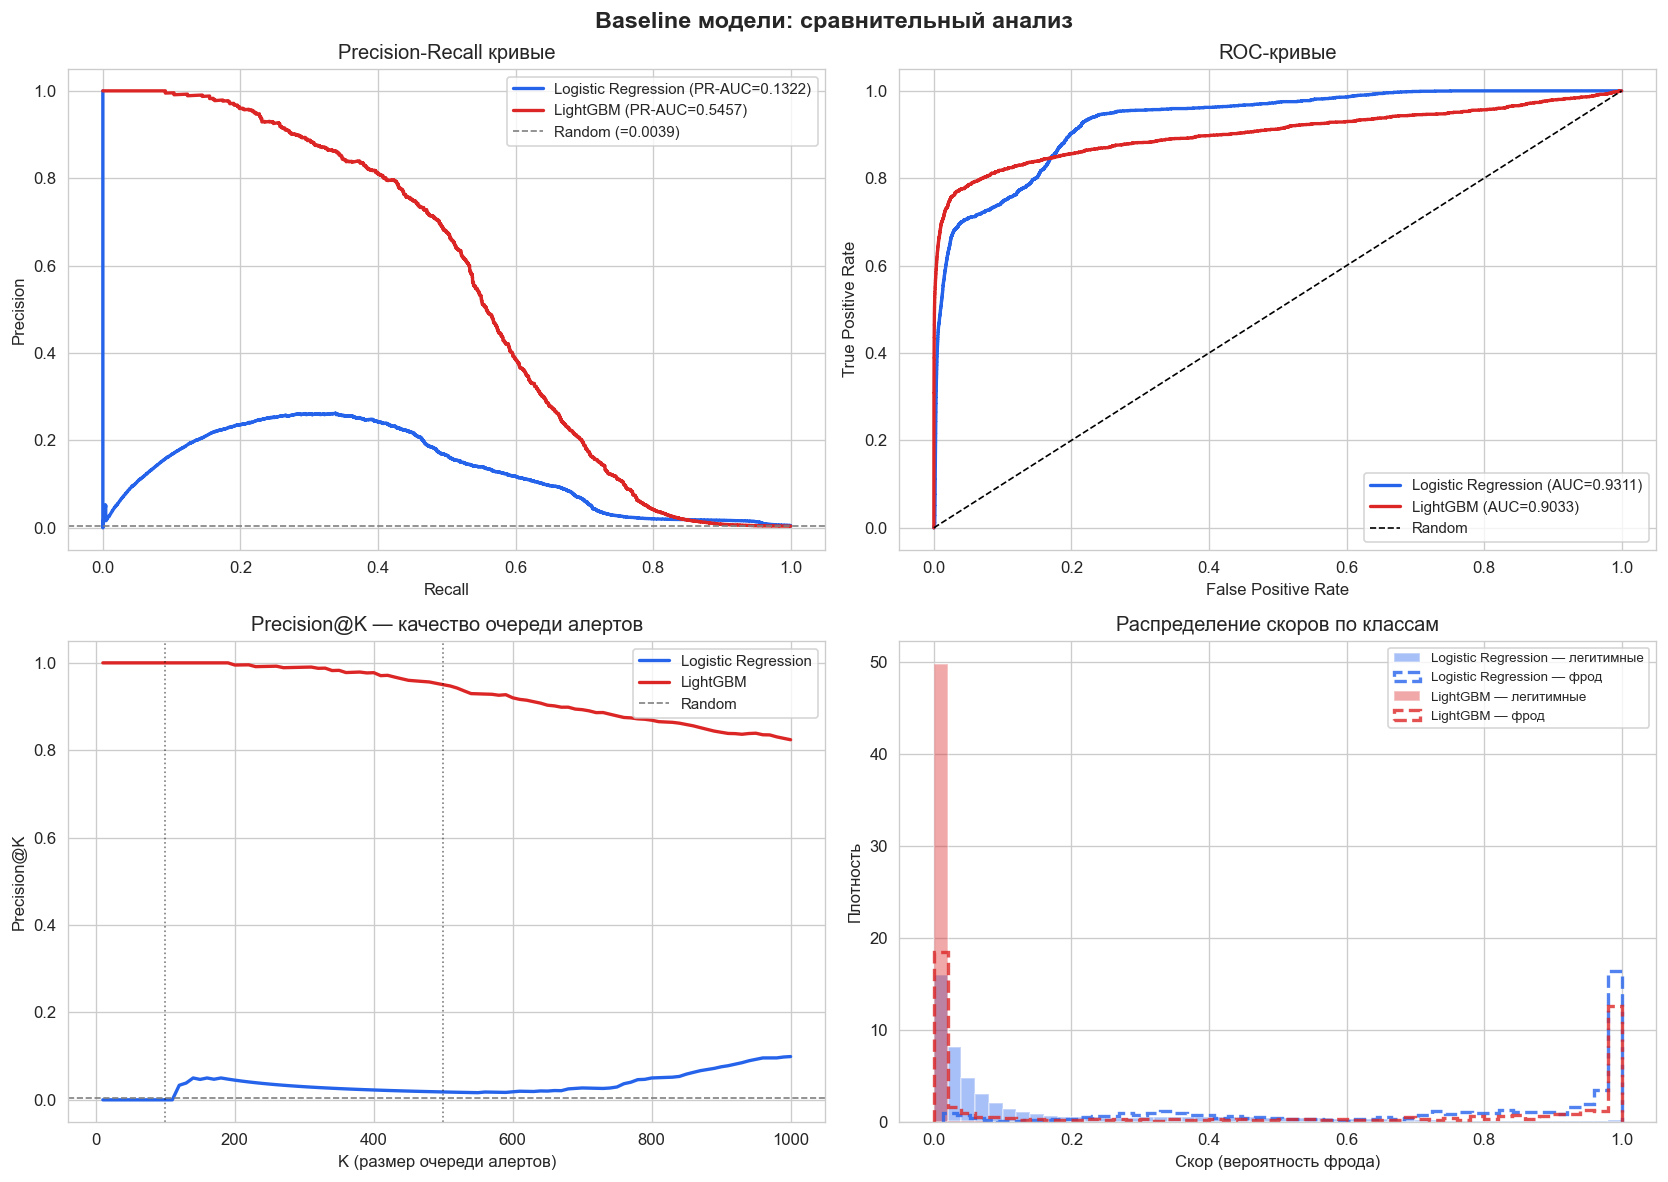

График сохранён: results/baseline_comparison.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Baseline модели: сравнительный анализ", fontsize=14, fontweight="bold")

# 1. PR-кривые
ax = axes[0, 0]
for name, scores, color in [
    ("Logistic Regression", lr_scores,   PALETTE["lr"]),
    ("LightGBM",            lgbm_scores, PALETTE["lgbm"]),
]:
    prec, rec, _ = precision_recall_curve(y_test, scores)
    auc = average_precision_score(y_test, scores)
    ax.plot(rec, prec, color=color, lw=2, label=f"{name} (PR-AUC={auc:.4f})")

ax.axhline(y=y_test.mean(), color="gray", linestyle="--",
           lw=1, label=f"Random (={y_test.mean():.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall кривые")
ax.legend(fontsize=9)

# 2. ROC-кривые
ax = axes[0, 1]
for name, scores, color in [
    ("Logistic Regression", lr_scores,   PALETTE["lr"]),
    ("LightGBM",            lgbm_scores, PALETTE["lgbm"]),
]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC-кривые")
ax.legend(fontsize=9)

# 3. Precision@K
ax = axes[1, 0]
k_values = list(range(10, 1001, 10))

for name, scores, color in [
    ("Logistic Regression", lr_scores,   PALETTE["lr"]),
    ("LightGBM",            lgbm_scores, PALETTE["lgbm"]),
]:
    ranked_idx = np.argsort(scores)[::-1]
    y_ranked   = y_test.values[ranked_idx]
    prec_at_k  = [y_ranked[:k].mean() for k in k_values]
    ax.plot(k_values, prec_at_k, color=color, lw=2, label=name)

ax.axhline(y=y_test.mean(), color="gray", linestyle="--",
           lw=1, label="Random")
ax.axvline(x=100, color="black", linestyle=":", lw=1, alpha=0.5)
ax.axvline(x=500, color="black", linestyle=":", lw=1, alpha=0.5)
ax.set_xlabel("K (размер очереди алертов)")
ax.set_ylabel("Precision@K")
ax.set_title("Precision@K — качество очереди алертов")
ax.legend(fontsize=9)

# 4. Распределение скоров
ax = axes[1, 1]
for name, scores, color in [
    ("Logistic Regression", lr_scores,   PALETTE["lr"]),
    ("LightGBM",            lgbm_scores, PALETTE["lgbm"]),
]:
    ax.hist(scores[y_test == 0], bins=50, alpha=0.4, color=color,
            label=f"{name} — легитимные", density=True)
    ax.hist(scores[y_test == 1], bins=50, alpha=0.8, color=color,
            label=f"{name} — фрод", density=True, linestyle="dashed",
            histtype="step", linewidth=2)

ax.set_xlabel("Скор (вероятность фрода)")
ax.set_ylabel("Плотность")
ax.set_title("Распределение скоров по классам")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS / "baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("График сохранён: results/baseline_comparison.png")

## 7. Сохранение результатов

Сохраняем скоры обеих моделей в `results/` — они будут загружены
в Notebook 6 для финального сравнения всех методов.

Формат: CSV с колонками `y_true` и `score` — минимально необходимый
набор для пересчёта любых метрик в Notebook 6.

In [12]:
import joblib

# Скоры для Notebook 6
for name, scores in [("lr", lr_scores), ("lgbm", lgbm_scores)]:
    pd.DataFrame({
        "y_true": y_test.values,
        "score":  scores,
    }).to_csv(RESULTS / f"scores_{name}.csv", index=False)
    print(f"Скоры сохранены: results/scores_{name}.csv")

# Сводная таблица метрик
metrics_df.to_csv(RESULTS / "metrics_baseline.csv")
print("Метрики сохранены: results/metrics_baseline.csv")

# Модели
joblib.dump(lr_pipeline,  MODELS / "lr_pipeline.pkl")
joblib.dump(lgbm_model,   MODELS / "lgbm_model.pkl")
print("Модели сохранены: models/lr_pipeline.pkl, models/lgbm_model.pkl")

# Параметры Optuna
with open(MODELS / "lgbm_best_params.json", "w") as f:
    json.dump(study.best_params, f, indent=2)
print("Параметры LightGBM сохранены: models/lgbm_best_params.json")

Скоры сохранены: results/scores_lr.csv
Скоры сохранены: results/scores_lgbm.csv
Метрики сохранены: results/metrics_baseline.csv
Модели сохранены: models/lr_pipeline.pkl, models/lgbm_model.pkl
Параметры LightGBM сохранены: models/lgbm_best_params.json


## 8. Итоги Notebook 2

### Результаты baseline моделей

| Метрика | Logistic Regression | LightGBM |
|---|---|---|
| ROC-AUC | 0.9311 | 0.9033 |
| PR-AUC | 0.1322 | 0.5457 |
| F1 | 0.3042 | 0.5765 |
| Precision@100 | 0.0000 | 1.0000 |
| Recall@100 | 0.0000 | 0.0466 |
| NDCG@100 | 0.0000 | 1.0000 |
| Precision@500 | 0.0180 | 0.9500 |
| Recall@500 | 0.0042 | 0.2214 |
| NDCG@500 | 0.0182 | 0.9587 |
| Inference | 1.8 мс | 155.9 мс |

### Ключевые выводы

- **LightGBM** является сильным baseline и устанавливает высокую планку
  для методов рекомендательных систем — особенно по метрикам ранжирования
- **Logistic Regression** подтверждает что задача не решается линейными
  зависимостями: нелинейные взаимодействия между признаками критически
  важны для качественного ранжирования
- **PR-AUC** является более информативной метрикой чем ROC-AUC при данном
  уровне дисбаланса классов, LR обманчиво высокий ROC-AUC (0.931)
  не отражает реальное качество модели
- Результаты Precision@100 = 1.0 для LightGBM отражают специфику
  синтетического датасета с чёткими паттернами фрода, в реальных данных такого результата ожидать не следует

Все результаты сохранены в `results/` для финального сравнения в Notebook 6.